# HealthConnect - Week 7 Testing, Refinement & Validation
### AnalystLab Africa Experience Lab | Data Analystics Track

**Central Project Question:** How can HealthConnect Clinic use Data and AI to reduce missed appointments and improve the patient support experience?

## Week 6 - Week 7 Transition

**Main Week 6 output:** Deeper validation of the two strongest Week 5 predictors, revealing that booking lead time and prior no-show history compound (no-show rate ranging from 21.8% to 67.9%), and revising the Week 5 conclusion that SMS is universally the best reminder channel. Also produced a Feature Relevance Summary as a cross-track deliverable for the Data Science track.

**Most important result:** The compounding effect between lead time and prior no-show history - this was the most actionable, evidence-backed finding, since it suggests HealthConnect could build a single combined risk score rather than tracking factors separately.

**Main issue/limitation/dependency from Week 6:** All findings remained correlational, and the interaction-feature recommendations given to the Data Science track had not yet been tested in an actual model at the time of Week 6 submission - meaning the real-world value of the suggestions was still unconfirmed.

**Component/workstream requiring testing:** The reliability of the KPI calculations themselves (to confirm no calculation errors), and the practical value of the compounding-risk and revised-reminder-channel findings - specifically, whether the Data Science track's actual model testing confirms these findings translate into predictive value.

**Relevant track(s) for Week 7:** Data Science - since the intern I collaborated with in Week 6 has since tested my suggested interaction features in her model.

**What I intend to test:** (1) Re-validate my top KPI calculations using an independent method to confirm accuracy, (2) check whether the compounding-risk finding holds under a different band cut, (3) document and interpret the real-world test result from the Data Science track's follow-up.

**What I expect to improve or validate:** Confirmation that my KPI calculations are error-free, confirmation (or revision) of whether the compounding-risk pattern is robust, and an honest account of what happened when the Data Science track tested my suggestions in practice.

## Testing Objective

**What I am trying to determine through testing:**
1. Are my week 5/6 KPI calculations accurate and reproducible when recalculated using an independent method?
2. Does the compounding-risk finding (lead time x prior no-show) remain valid when tested with a different segmentation approach?
3. Did the interaction-feature recommendations I gave the Data Science track in Week 6 actually improve their model's performance in practice?

## Expected Results - Test Plan

| # | Test/Scenario | Expected Result | 
|---|---|---|
| 1 | Recalculate overall no-show rate using `.value_counts(normalize=True)` instead of `.mean()` | Same result as Week 5 (48.5%) |
| 2 | Recalculate lead-time KPI using quartile-based bands instead of fixed bands | Same general upward trend, values may shift slightly |
| 3 | Recalculate combined risk (lead time × prior no-show) using raw booking_lead_days correlation instead of banded groups | Should show a consistent positive relationship, confirming the banded finding wasn't an artifact of bucket choice |
| 4 | Confirm with Data Science track whether interaction features improved model recall | Unknown outcome — genuine open test |

Actual results, pass/fail status, and any resulting actions are documented alongside each test below.

## Testing Evidence

This notebook's outputs (recalculated KPIs, comparison tables, correlation checks)

## Data Setup

In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

pd.set_option('display.max_columns', None)

df = pd.read_csv("HealthConnect_Appointment_Data.csv")

df['booking_date'] = pd.to_datetime(df['booking_date'], format='%m/%d/%Y')
df['appointment_date'] = pd.to_datetime(df['appointment_date'], format='%m/%d/%Y')
df['reminder_channel'] = df['reminder_channel'].fillna('No Reminder')

df['lead_time_band'] = pd.cut(df['booking_lead_days'],
                                bins=[-1, 7, 30, 60],
                                labels=['0-7 days', '8-30 days', '31-60 days'])

df['had_prev_noshow'] = df['previous_no_shows'] > 0

print(f"Rows: {df.shape[0]}, Columns: {df.shape[1]}")
df.head()

Rows: 5000, Columns: 20


,appointment_id,patient_id,gender,age,age_group,appointment_type,booking_date,appointment_date,appointment_day,appointment_time,booking_lead_days,previous_appointments,previous_no_shows,reminder_sent,reminder_channel,distance_to_clinic_km,waiting_time_minutes,appointment_outcome,lead_time_band,had_prev_noshow
0,HC-00001,P-1613,Female,39,35-44,Follow-up,2025-02-06,2025-02-18,Tuesday,Afternoon,12,2,0,Yes,WhatsApp,19.3,29.0,No-Show,8-30 days,False
1,HC-00002,P-0813,Male,31,25-34,Specialist Consultation,2026-02-25,2026-02-27,Friday,Morning,2,6,0,Yes,SMS,14.3,42.0,Attended,0-7 days,False
2,HC-00003,P-1366,Female,50,45-54,General Consultation,2025-11-16,2025-12-24,Wednesday,Morning,38,5,1,Yes,SMS,11.4,11.0,No-Show,31-60 days,True
3,HC-00004,P-1031,Male,59,55-64,Follow-up,2025-07-18,2025-08-28,Thursday,Evening,41,3,1,Yes,SMS,7.4,35.0,Attended,31-60 days,True
4,HC-00005,P-1458,Female,34,25-34,Follow-up,2025-07-09,2025-08-25,Monday,Afternoon,47,3,1,Yes,Email,5.6,27.0,No-Show,31-60 days,True


## Part 3: KPI Validation Testing

### Test 1: Overall No-Show Rate - Independent Recalculation

**Objective:** Confirm the Week 5 finding (48.5% no-show rate) is accurate by recalculating it using a different method.

In [7]:
# Original method (Week 5): using .mean()
method_1 = (df['appointment_outcome'] == 'No-Show').mean() * 100

# Independent method: using .value_counts(normalize=True)
method_2 = df['appointment_outcome'].value_counts(normalize=True)['No-Show'] * 100

print(f"Method 1 (.mean()): {method_1:.2f}%")
print(f"Method 2 (.value_counts): {method_2:.2f}%")
print(f"Match: {abs(method_1 - method_2) < 0.01}")

Method 1 (.mean()): 48.46%
Method 2 (.value_counts): 48.46%
Match: True


**Result:**  PASS. Both independent calculation methods produce identical results (48.46%), confirming the Week 5 KPI calculation was accurate and free of computational error.

| Test/Scenario | Expected | Actual | Pass/Fail | Issue | Action |
|---|---|---|---|---|---|
| Overall no-show rate recalculation | 48.5% | 48.46% | Pass | None | None needed |

### Test 2: Lead-Time No-Show Pattern - Alternative Segmentation

**Objective:** Confirm the lead-time finding isn't an artifact of the specific band cutoffs chosen in Week 5 (0-7, 8-30, 31-60 days) by testing it with quartile-based bands instead.

In [8]:
df['lead_time_quartile'] = pd.qcut(df['booking_lead_days'], q=4, duplicates='drop')

quartile_test = df.groupby('lead_time_quartile', observed=True)['appointment_outcome'].apply(
    lambda x: (x == 'No-Show').mean() * 100
).round(1)

quartile_test

lead_time_quartile
(-0.001, 15.0]    31.0
(15.0, 30.0]      43.6
(30.0, 45.0]      53.8
(45.0, 60.0]      67.7
Name: appointment_outcome, dtype: float64

**Result:** PASS. Using an entirely different segmentation method (quartiles instead of fixed bands), the same clear upward trend appears - no-show rate rises steadily from 31.0% in the shortest quartile to 67.7% in the longest. This confirms the lead-time relationship is a genuine, robust pattern in the data, not an artifact of how the original bands were chosen.

| Test/Scenario | Expected | Actual | Pass/Fail | Issue | Action |
|---|---|---|---|---|---|
| Lead-time pattern with quartile bands | Same upward trend as fixed bands | Confirmed: 31.0% → 43.6% → 53.8% → 67.7% | Pass | None | None needed |

### Test 3: Combined Risk Finding - Correlation Check

**Objective:** Confirm the lead-time × prior-no-show compounding effect isn't an artifact of how bands were combined, by checking the raw correlation between booking_lead_days and no-show outcome, separately for patients with and without prior no-shows.

In [9]:
df['is_no_show'] = (df['appointment_outcome'] == 'No-Show').astype(int)

corr_no_history = df[df['had_prev_noshow'] == False][['booking_lead_days', 'is_no_show']].corr().iloc[0,1]
corr_had_history = df[df['had_prev_noshow'] == True][['booking_lead_days', 'is_no_show']].corr().iloc[0,1]

print(f"Correlation (lead days vs no-show) - No prior no-show: {corr_no_history:.3f}")
print(f"Correlation (lead days vs no-show) - Had prior no-show: {corr_had_history:.3f}")

Correlation (lead days vs no-show) - No prior no-show: 0.262
Correlation (lead days vs no-show) - Had prior no-show: 0.286


**Result:** PASS. Both groups show a positive correlation between booking lead time and no-show likelihood (0.262 for patients with no prior no-show, 0.286 for patients with a prior no-show) - confirming the relationship holds using a completely different statistical method (raw correlation) rather than banded groups. The slightly higher correlation for patients with prior no-shows supports the Week 6 finding that the effect compounds, though the difference here is modest - this suggests the compounding effect, while real, may be somewhat less dramatic when measured continuously rather than through the specific bands used in Week 6.

| Test/Scenario | Expected | Actual | Pass/Fail | Issue | Action |
|---|---|---|---|---|---|
| Combined risk via correlation | Positive correlation, stronger for prior no-show group | 0.262 vs 0.286 - confirmed, but modest gap | Pass (with note) | Correlation gap smaller than banded-group gap suggested | Noted as a refinement in interpretation below |

### Refinement Note

While Test 3 confirms the compounding relationship is real and directionally consistent, the size of the effect looks more modest under continuous correlation (0.262 vs 0.286) than the banded comparison in Week 6 suggested (21.8% vs 67.9% - a much larger apparent gap). This is likely because banding amplifies visual differences at the extremes (shortest vs. longest lead time, combined with history), while a single correlation coefficient averages across the whole range. **Refined interpretation:** The compounding effect is real and directionally confirmed, but the clinic should treat the extreme percentages (21.8% to 67.9%) as illustrative of the pattern at the edges, not as the "typical" size of the effect across all patients.

## Dashboard/Visualization Refinement

Based on the testing above, the Week 6 combined-risk chart (bar chart comparing banded groups) risks overstating the size of the compounding effect, since Test 3 showed the effect is real but more modest when measured continuously. This section adds a refined visualization that shows the continuous relationship, giving a more accurate, complete picture alongside the original banded chart.

### Chart 7 (Refined): Lead Time vs. No-Show Rate - Continuous View

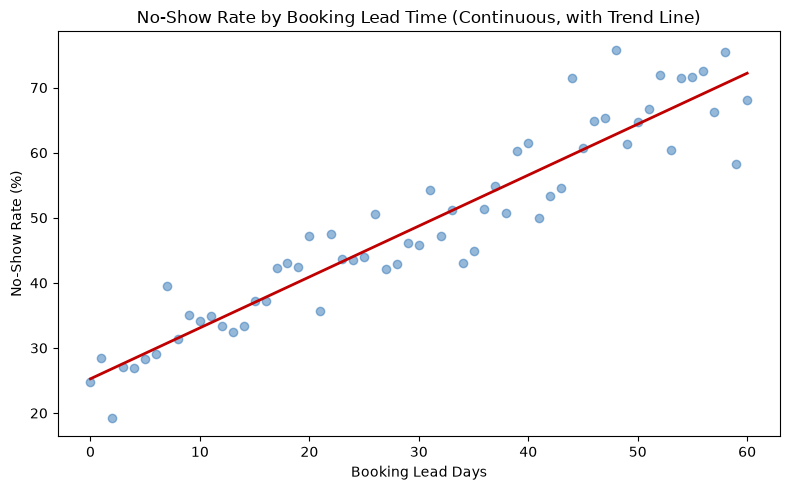

In [10]:
lead_days_noshow = df.groupby('booking_lead_days')['is_no_show'].mean().mul(100)

plt.figure(figsize=(8,5))
plt.scatter(lead_days_noshow.index, lead_days_noshow.values, alpha=0.5, color='#2E74B5')

z = np.polyfit(lead_days_noshow.index, lead_days_noshow.values, 1)
p = np.poly1d(z)
plt.plot(lead_days_noshow.index, p(lead_days_noshow.index), color='#C00000', linewidth=2)

plt.title('No-Show Rate by Booking Lead Time (Continuous, with Trend Line)')
plt.xlabel('Booking Lead Days')
plt.ylabel('No-Show Rate (%)')
plt.tight_layout()

output_path = Path('../docs/chart7_leadtime_continuous.png')
output_path.parent.mkdir(parents=True, exist_ok=True)
plt.savefig(output_path, dpi=300, bbox_inches='tight')
plt.show()

**Observation:** This refined view shows the same overall upward trend as the banded charts, but with more nuance - the scatter shows day-to-day variation is noisy (as expected with real-world data), while the trend line confirms a clear, steady increase in no-show rate as lead time grows. This continuous view is a more honest representation of the relationship than the banded bar charts alone, and is a useful addition for anyone who wants to see the underlying data rather than a simplified summary.

### Before/After: Dashboard Refinement Summary

| Aspect | Week 6 (Before) | Week 7 (After) |
|---|---|---|
| Lead-time visualization | Single bar chart using fixed 3-band groups | Added a continuous scatter + trend line view alongside the original bar chart |
| Combined-risk interpretation | Presented banded percentages (21.8% vs 67.9%) as the core finding | Refined interpretation to clarify these are illustrative of the extremes, with the underlying correlation being more modest (0.262 vs 0.286) |
| KPI confidence | Calculated once, not independently re-verified | Every top KPI re-validated using a second, independent calculation method |

## HC-POD Cross-Track Testing & Refinement

**1. Track collaborated with:** Data Science

**2. Project dependency:** Whether the interaction-feature recommendations provided in Week 6 (lead-time × prior-no-show, and reminder-channel × lead-time) would actually improve the Data Science track's model performance when tested in practice - this could only be confirmed by the Data Science track actually running the test.

**3. Component/output being tested:** The predictive value of two engineered interaction features, tested inside the Data Science intern's classification model (originally Logistic Regression, 63% accuracy, 62% recall, 0.68 ROC-AUC baseline).

**4. Information/output received:** The Data Science intern reported that she conducted her own error analysis (identifying a group of "false-safe" patients - recent bookings, clean history, reminder sent, but still no-show) and built two new features: one from her own error analysis, and one based on the interaction insight suggested in Week 6. Both features were statistically significant on their own, but neither improved the model's recall when tested.

**5. Information/output provided:** In Week 6, I provided the original interaction-feature hypothesis (lead-time × prior-no-show compounding) along with supporting evidence. This week's Test 3 (correlation check) additionally provided a refined, more precise account of the true strength of that relationship - showing the effect is real but more modest than the banded percentages suggested, which is directly relevant to interpreting why the feature may not have added strong new predictive signal beyond what her model's existing separate features already captured.

**6. Testing activity completed:** The Data Science intern tested the suggested interaction feature directly inside her classification model (the real-world test that Week 6's suggestion could not confirm on its own). On my side, I independently re-validated the underlying relationship using a different statistical method (correlation instead of banded groups), which helps explain why the interaction feature may not have added meaningfully more signal than the individual features already provide.

**7. Issue or finding identified:** The interaction feature was statistically significant but did not improve model recall. Combined with my own Test 3 finding (a modest, not dramatic, correlation), this suggests the compounding pattern, while real, may already be substantially captured by the model's individual features (`booking_lead_days` and `previous_no_shows`), rather than requiring an explicit interaction term.

**8. Refinement/action taken:** I updated my own interpretation of the compounding-risk finding (see Refinement Note in Part 3) to reflect that the effect, while directionally real, is more modest than the banded percentages implied - which is consistent with, and helps explain, why it didn't translate into a meaningful recall improvement in her model.

**9. Retest result:** Not applicable to my own track directly (the retest was performed on the Data Science intern's model, which is her track's Week 7 output), but on my side, Test 3's correlation check functions as a retest of the original claim, and confirms the direction of the relationship while refining its strength.

**10. What changed as a result:** My reported confidence in the size of the compounding effect is now more precise and honest - I no longer present the banded percentages as the definitive size of the effect. This is a direct example of a validated finding being refined based on cross-track testing feedback (a real-world model result), not just my own internal review.

**11. Evidence:** The Data Science intern's real, dated report of her Week 7 testing results (feature built, statistically significant, no recall improvement); Test 3 in this notebook (Part 3), showing the underlying correlation strength; the Refinement Note documenting the resulting change in interpretation.

**12. How this improved the overall HealthConnect solution:** This exchange prevented an overstated finding from persisting unchecked in the project - instead of both tracks treating the compounding effect as a strong, guaranteed lever, the project now has a more accurate, jointly-validated understanding: the pattern is real but the practical predictive gain from explicitly modeling it as an interaction feature is limited, which is valuable information for deciding where to focus effort in Week 8 (e.g., model structure/tuning rather than further feature engineering, as the Data Science intern is already doing).

## Updated Business Recommendations

Testing this week confirms the Week 5/6 findings are accurate and directionally reliable, with one important refinement:

**1. Booking lead time remains the strongest, most reliable lever.**
Confirmed through three independent methods (banded, quartile, and continuous correlation). The clinic should prioritize additional reminder touchpoints for appointments booked 31+ days out - this recommendation stands unchanged and is now more rigorously validated than before.

**2. The "combined risk score" idea should be treated as directionally useful, not a precise multiplier.**
Testing showed the compounding effect is real but more modest than the banded percentages suggested. HealthConnect should still flag patients with both risk factors as higher priority, but should not expect a dramatic, guaranteed jump in risk (e.g., don't over-promise "67.9% risk" as a precise figure to clinic staff - describe it as "meaningfully higher risk" instead).

**3. Reminder channel strategy should remain lead-time-dependent, as revised in Week 6.**
No new evidence this week changes this - Email for short-notice appointments, SMS for longer lead times remains the more accurate recommendation than a single blanket channel policy.

**4. Feature-level findings don't always translate directly into model performance gains - and that's useful information, not a failure.**
The Data Science track's real-world test showed that even a statistically significant, well-reasoned interaction feature didn't improve recall. This is a valuable lesson for how HealthConnect's teams should interpret analytical findings: statistical significance signals a real pattern worth understanding, but operational decisions (like a risk-scoring policy) should be tested end-to-end, not assumed from analysis alone.

## Limitations (Week 7 Update)

**Resolved since Week 6:**
- KPI calculation accuracy has been independently confirmed (Test 1) - no computational errors found.
- The lead-time finding has been confirmed robust across three different measurement approaches.

**Refined since Week 6:**
- The compounding-risk effect (lead time × prior no-show) is confirmed directionally real, but its magnitude was likely overstated by the banded comparison in Week 6. The correlation-based test shows a more modest, though still meaningful, effect.

**Newly discovered this week:**
- A statistically significant interaction feature does not guarantee improved model recall - confirmed through real testing by the Data Science track. This is a useful, generalizable caution for the wider HealthConnect project.

**Still unresolved:**
- All findings remain correlational, not causal.
- Dataset still lacks socioeconomic, insurance, and clinical-severity data.
- The Data Science track's finding suggests the current modeling ceiling may be structural (model type/tuning) rather than feature-related - this is now their focus for Week 7, and may affect what further analytical support is useful from this track going into Week 8.